## This notebook makes a plot showing SCF. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
import plot_scripts as plts
import os
plt.style.use("mplstyle")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# --- Input Model Parameters ---
n = 2.0
N = 768
dnuc = 40e-3             # MHz
r = 9209.714526830916    # Mpc
rp = 16.98990953034521   # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100

# Try loading nua, else create dummy frequency array
try:
    nua = np.load('nua.npy') / 1e6
    dnu = nua
except FileNotFoundError:
    print("Warning: 'nua.npy' not found. Using linear range.")
    dnu = np.arange(N) * dnuc + 138.0 

# --- Configuration ---
path = "results"
flag_mode = "NOFLAG"  # Updated to RANDOM
NN_hann = 50 
show_inset = False 

# INDICES for the two realizations
idx1 = 45
idx2 = 90 

# --- Helper to load data ---
def get_data(inp_sig, scf_method, idx):
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None, None
    data = np.load(fname)
    orig = data.get("fields_orig", None)
    val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
    return data["fields_tota"][idx], data["fields_flag"][idx], val_orig

def get_data21(inp_sig, scf_method, idx):
    # Loads NOFLAG data for the "Truth"
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None, None
    data = np.load(fname)
    orig = data.get("fields_orig", None)
    val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
    return data["fields_tota"][idx], data["fields_flag"][idx], val_orig
    
tota_fg_hann, res_hann, _ = get_data("FG+MM+21cm", "Hann", idx=idx1)



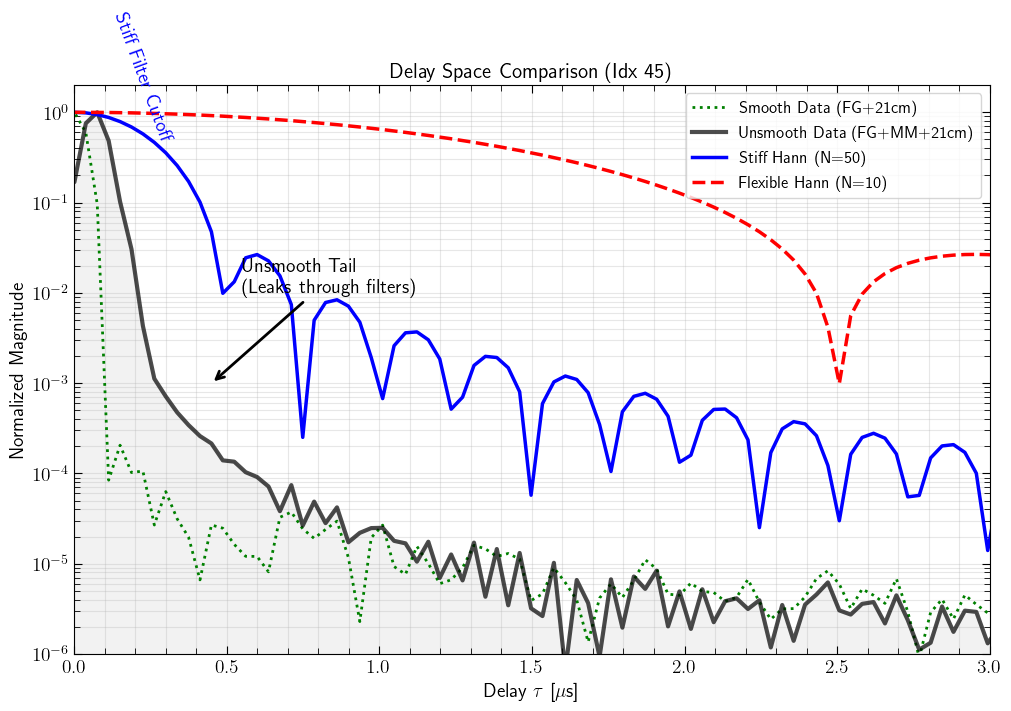

Plot saved to plots/Delay_Comparison_Smooth_vs_Unsmooth_N50_N10.pdf


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.fft import fft, fftshift, fftfreq

# === 1. Parameters ===
N = 768
dnuc = 40e-3             # MHz (0.04 MHz)

# Load Frequency Array
try:
    nua = np.load('nua.npy') 
except FileNotFoundError:
    print("Warning: 'nua.npy' not found. Using linear range.")
    nua = np.arange(N) * dnuc + 138.0

# Window params
NN_stiff = 50   # Stiff / Wide Window
NN_flex = 10    # Flexible / Narrow Window

path = "results"
flag_mode = "NOFLAG"
idx1 = 45 

# === 2. Data Loading ===

def get_data_from_file(filename_type, idx):
    """
    filename_type: 'FG+21cm' (Smooth) or 'FG+MM+21cm' (Unsmooth)
    """
    fname = f"{path}/fields_inp_signal-{filename_type}_flag-{flag_mode}_SCF-Hann.npz"
    
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None
        
    data = np.load(fname)
    total = data["fields_tota"][idx]
    
    # Slice to Valid Region (Crucial for correct FFT)
    # We use the largest exclusion (NN_stiff) for consistency across all plots
    valid_slice = slice(NN_stiff, -NN_stiff)
    return total[valid_slice]

# === 3. Analysis Helpers ===

def compute_delay_spec(signal):
    # Blackman window to kill edge ringing in FFT
    win = np.blackman(len(signal))
    # win = 1
    spec = np.abs(fftshift(fft(signal * win)))
    delays = fftshift(fftfreq(len(signal), d=dnuc))
    return delays, spec

def get_hann_transfer(N_len, N_half):
    # Construct window in the same size buffer
    win = np.zeros(N_len)
    hann = np.hanning(2 * N_half + 1)
    
    center = N_len // 2
    start = center - N_half
    end = start + len(hann)
    if end > N_len: end = N_len
    
    win[start:end] = hann[:end-start]
    win /= win.sum()
    
    return np.abs(fftshift(fft(win)))

# === MAIN PLOT ===

# A. Get Data from Files
data_smooth   = get_data_from_file("FG+21cm", idx1)      # Smooth Reference
data_unsmooth = get_data_from_file("FG+MM+21cm", idx1)   # Unsmooth Target

if data_smooth is not None and data_unsmooth is not None:
    # B. Compute Spectra
    delays, spec_smooth   = compute_delay_spec(data_smooth)
    _,      spec_unsmooth = compute_delay_spec(data_unsmooth)
    
    # C. Compute Filters
    N_len = len(data_smooth)
    W_stiff = get_hann_transfer(N_len, NN_stiff) # N=50
    W_flex  = get_hann_transfer(N_len, NN_flex)  # N=10
    
    # D. Normalize Everything to Peak = 1.0
    # Normalize data by THEIR OWN maximums to compare shapes (widths)
    spec_s_norm = spec_smooth / np.max(spec_smooth)
    spec_u_norm = spec_unsmooth / np.max(spec_unsmooth)
    
    # Normalize filters to 1.0
    W_stiff_norm = W_stiff / np.max(W_stiff)
    W_flex_norm  = W_flex  / np.max(W_flex)

    # E. Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # 1. Plot Data
    ax.plot(delays, spec_s_norm, color='green', linestyle=':', lw=2, label='Smooth Data (FG+21cm)')
    ax.plot(delays, spec_u_norm, 'k-', lw=3, alpha=0.7, label='Unsmooth Data (FG+MM+21cm)')
    
    # Fill under unsmooth to highlight the "bulk"
    ax.fill_between(delays, spec_u_norm, color='gray', alpha=0.1)

    # 2. Plot Filters
    ax.plot(delays, W_stiff_norm, 'b-', lw=2.5, label=f'Stiff Hann (N={NN_stiff})')
    ax.plot(delays, W_flex_norm,  'r--', lw=2.5, label=f'Flexible Hann (N={NN_flex})')
    
    # Annotations
    ax.text(0.12, 0.5, "Stiff Filter Cutoff", color='blue', fontweight='bold', rotation=-70)
    
    # Arrow showing the difference
    ax.annotate('Unsmooth Tail\n(Leaks through filters)', 
                xy=(0.45, 1e-3), xytext=(0.55, 1e-2),
                arrowprops=dict(facecolor='black', arrowstyle='->', lw=2),
                fontweight='bold')

    # Formatting
    ax.set_yscale('log')
    ax.set_xlim(0, 3) # Focus on relevant delays
    ax.set_ylim(bottom=1e-6, top=2.0)
    
    ax.set_xlabel(r'Delay $\tau$ [$\mu$s]', fontsize=14)
    ax.set_ylabel(r'Normalized Magnitude', fontsize=14)
    ax.set_title(f'Delay Space Comparison (Idx {idx1})', fontsize=15)
    ax.legend(fontsize=12, loc='upper right')
    ax.grid(True, which='both', alpha=0.3)
    
    save_fname = f"plots/Delay_Comparison_Smooth_vs_Unsmooth_N{NN_stiff}_N{NN_flex}.pdf"
    os.makedirs(os.path.dirname(save_fname), exist_ok=True)
    plt.savefig(save_fname)
    plt.show()
    print(f"Plot saved to {save_fname}")
    
else:
    print("Could not load one or both data files. Check paths.")

/tmp/ipykernel_249602/1118528869.py:110: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


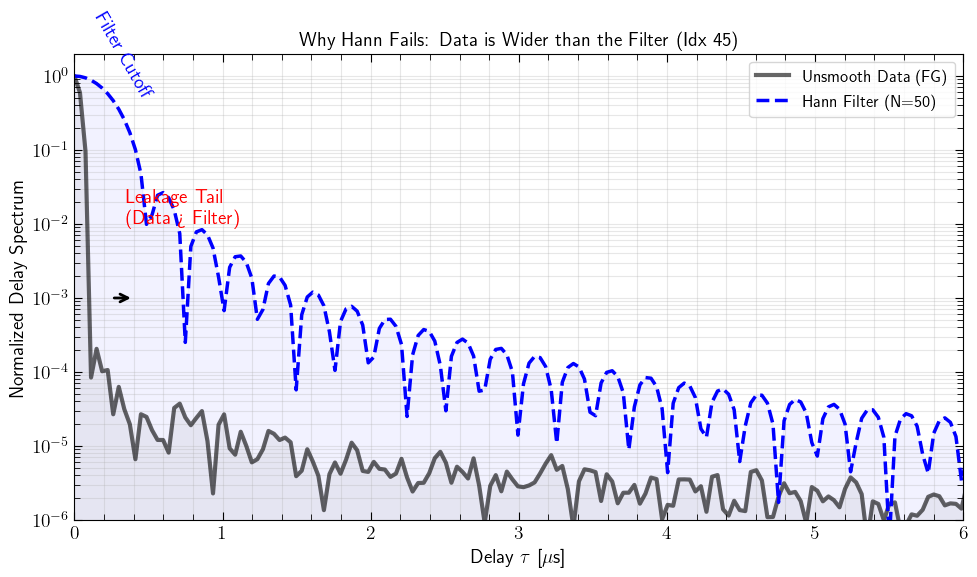

Plot saved.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.fft import fft, fftshift, fftfreq

# === 1. Parameters ===
N = 768
dnuc = 40e-3             # MHz (0.04 MHz)

# Try loading nua, else create dummy (Safety check)
try:
    nua = np.load('nua.npy') 
except FileNotFoundError:
    print("Warning: 'nua.npy' not found. Using linear range.")
    nua = np.arange(N) * dnuc + 138.0

# Window params
NN_hann = 50  
path = "results"
flag_mode = "NOFLAG"
idx1 = 45 # Realization Index

# === 2. Data Loading ===
def get_data_valid(idx):
    fname = f"{path}/fields_inp_signal-FG+21cm_flag-{flag_mode}_SCF-Hann.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None
    data = np.load(fname)
    
    # Get Total Data and Residuals
    total = data["fields_tota"][idx]
    
    # EXTRACT VALID REGION ONLY (Crucial for correct FFT)
    valid_slice = slice(NN_hann, -NN_hann)
    return total[valid_slice]

# === 3. FFT Helper ===
def compute_delay_spec(signal):
    # Blackman window to kill edge ringing
    win = np.blackman(len(signal))
    spec = np.abs(fftshift(fft(signal * win)))
    delays = fftshift(fftfreq(len(signal), d=dnuc))
    return delays, spec

# === 4. Hann Transfer Function ===
def get_hann_transfer(N_len, N_half):
    # Construct window in the same size buffer
    win = np.zeros(N_len)
    hann = np.hanning(2 * N_half + 1)
    
    center = N_len // 2
    start = center - N_half
    end = start + len(hann)
    if end > N_len: end = N_len
    
    win[start:end] = hann[:end-start]
    win /= win.sum() # Sum=1 ensures DC component is 1.0
    
    return np.abs(fftshift(fft(win)))

# === MAIN PLOT ===
data_valid = get_data_valid(idx1)

if data_valid is not None:
    # 1. Compute Spectra
    delays, spec_data = compute_delay_spec(data_valid)
    
    # 2. Compute Filter Curve
    W_response = get_hann_transfer(len(data_valid), NN_hann)
    
    # --- NORMALIZATION STEP ---
    # Normalize Data by its Maximum (Peak = 1.0)
    data_max = np.max(spec_data)
    spec_data_norm = spec_data / data_max
    
    # Filter is already normalized to DC=1 by construction (win.sum()), 
    # but we force max=1 just to be perfectly aligned for the plot.
    W_norm = W_response / np.max(W_response)

    # 3. Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot Normalized Data
    ax.plot(delays, spec_data_norm, 'k-', lw=3, alpha=0.6, label='Unsmooth Data (FG)')
    ax.fill_between(delays, spec_data_norm, color='gray', alpha=0.1)

    # Plot Normalized Filter
    ax.plot(delays, W_norm, 'b--', lw=2.5, label=f'Hann Filter (N={NN_hann})')
    ax.fill_between(delays, W_norm, color='blue', alpha=0.05)

    # Annotations
    ax.text(0.12, 0.5, "Filter Cutoff", color='blue', fontweight='bold', rotation=-60)
    ax.text(0.35, 1e-2, "Leakage Tail\n(Data > Filter)", color='red', fontweight='bold')
    
    ax.annotate('', xy=(0.4, 1e-3), xytext=(0.25, 1e-3),
                arrowprops=dict(facecolor='red', arrowstyle='->', lw=2))

    # Formatting
    ax.set_yscale('log')
    ax.set_xlim(0, 6) # Zoom on positive delays
    ax.set_ylim(bottom=1e-6, top=2.0) # Standard normalized range
    
    ax.set_xlabel(r'Delay $\tau$ [$\mu$s]', fontsize=14)
    ax.set_ylabel(r'Normalized Delay Spectrum', fontsize=14)
    ax.set_title(f'Why Hann Fails: Data is Wider than the Filter (Idx {idx1})', fontsize=14)
    ax.legend(fontsize=12, loc='upper right')
    ax.grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"plots/Delay_Space_Proof_Normalized_{idx1}.pdf")
    plt.show()
    print("Plot saved.")
else:
    print("Data load failed.")

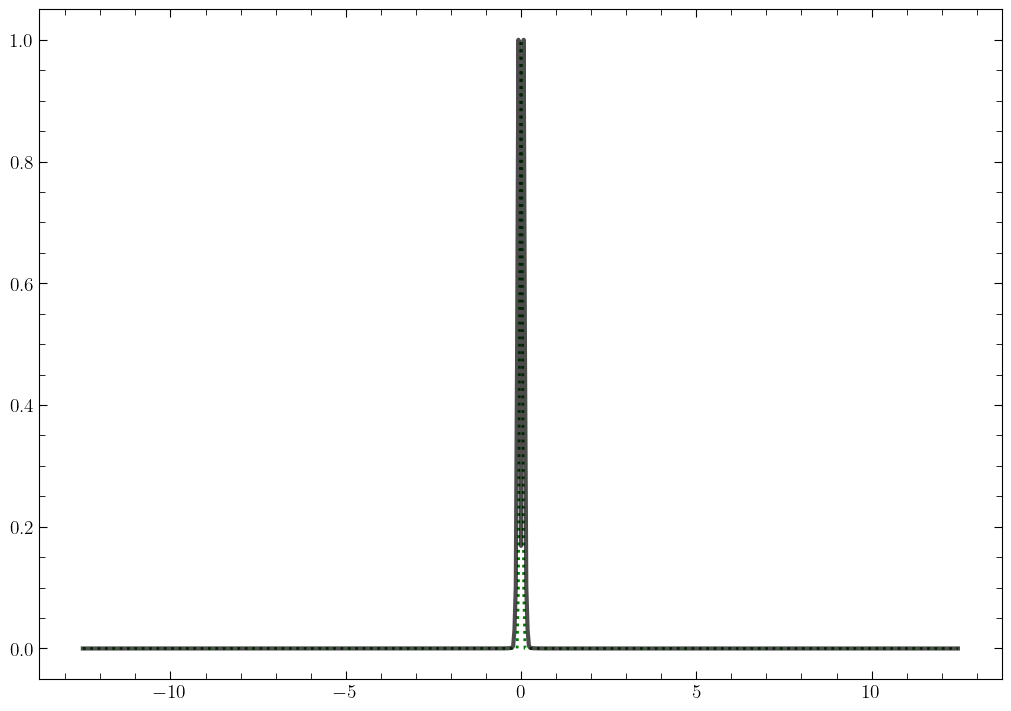

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.fft import fft, fftshift, fftfreq

# === 1. Parameters ===
N = 768
dnuc = 40e-3             # MHz (0.04 MHz)

# Load Frequency Array
try:
    nua = np.load('nua.npy') 
except FileNotFoundError:
    print("Warning: 'nua.npy' not found. Using linear range.")
    nua = np.arange(N) * dnuc + 138.0

# Window params
NN_stiff = 50   # Stiff / Wide Window
NN_flex = 10    # Flexible / Narrow Window

path = "results"
flag_mode = "NOFLAG" # Or "PERIODIC"
idx1 = 45 

# === 2. Data Loading ===

def get_data_from_file(filename_type, idx):
    """
    filename_type: 'FG+21cm' (Smooth) or 'FG+MM+21cm' (Unsmooth)
    """
    fname = f"{path}/fields_inp_signal-{filename_type}_flag-{flag_mode}_SCF-Hann.npz"
    
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None
        
    data = np.load(fname)
    total = data["fields_tota"][idx]
    
    # Slice to Valid Region (Crucial for correct FFT)
    # We use the largest exclusion (NN_stiff) for consistency
    valid_slice = slice(NN_stiff, -NN_stiff)
    return total[valid_slice]

# === 3. Analysis Helpers ===

def compute_delay_spec(signal):
    # Blackman window to kill edge ringing in FFT
    win = np.blackman(len(signal))
    spec = np.abs(fftshift(fft(signal * win)))
    delays = fftshift(fftfreq(len(signal), d=dnuc))
    return delays, spec

def get_hann_transfer(N_len, N_half):
    # Construct window in the same size buffer
    win = np.zeros(N_len)
    hann = np.hanning(2 * N_half + 1)
    
    center = N_len // 2
    start = center - N_half
    end = start + len(hann)
    if end > N_len: end = N_len
    
    win[start:end] = hann[:end-start]
    win /= win.sum()
    
    return np.abs(fftshift(fft(win)))

# === MAIN PLOT ===

# A. Get Data
data_smooth   = get_data_from_file("FG+21cm", idx1)      # Smooth
data_unsmooth = get_data_from_file("FG+MM+21cm", idx1)   # Unsmooth

if data_smooth is not None and data_unsmooth is not None:
    # B. Compute Spectra
    delays, spec_smooth   = compute_delay_spec(data_smooth)
    _,      spec_unsmooth = compute_delay_spec(data_unsmooth)
    
    # C. Compute Filters
    N_len = len(data_smooth)
    W_stiff = get_hann_transfer(N_len, NN_stiff) # N=50
    W_flex  = get_hann_transfer(N_len, NN_flex)  # N=10
    
    # D. Normalize Everything to Peak = 1.0
    # Normalize data by THEIR OWN maximums to compare shapes (widths)
    spec_s_norm = spec_smooth / np.max(spec_smooth)
    spec_u_norm = spec_unsmooth / np.max(spec_unsmooth)
    
    # Normalize filters to 1.0
    W_stiff_norm = W_stiff / np.max(W_stiff)
    W_flex_norm  = W_flex  / np.max(W_flex)

    # E. Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # 1. Plot Data
    ax.plot(delays, spec_s_norm, color='green', linestyle=':', lw=2, label='Smooth Data (FG+21cm)')
    ax.plot(delays, spec_u_norm, 'k-', lw=3, alpha=0.7, label='Unsmooth Data (FG+MM+21cm)')
    
    # Fill under unsmooth to highlight

/tmp/ipykernel_249602/738306770.py:143: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.1)


Saved: plots/Delay_Analysis_Hann_Valid_PERIODIC.pdf


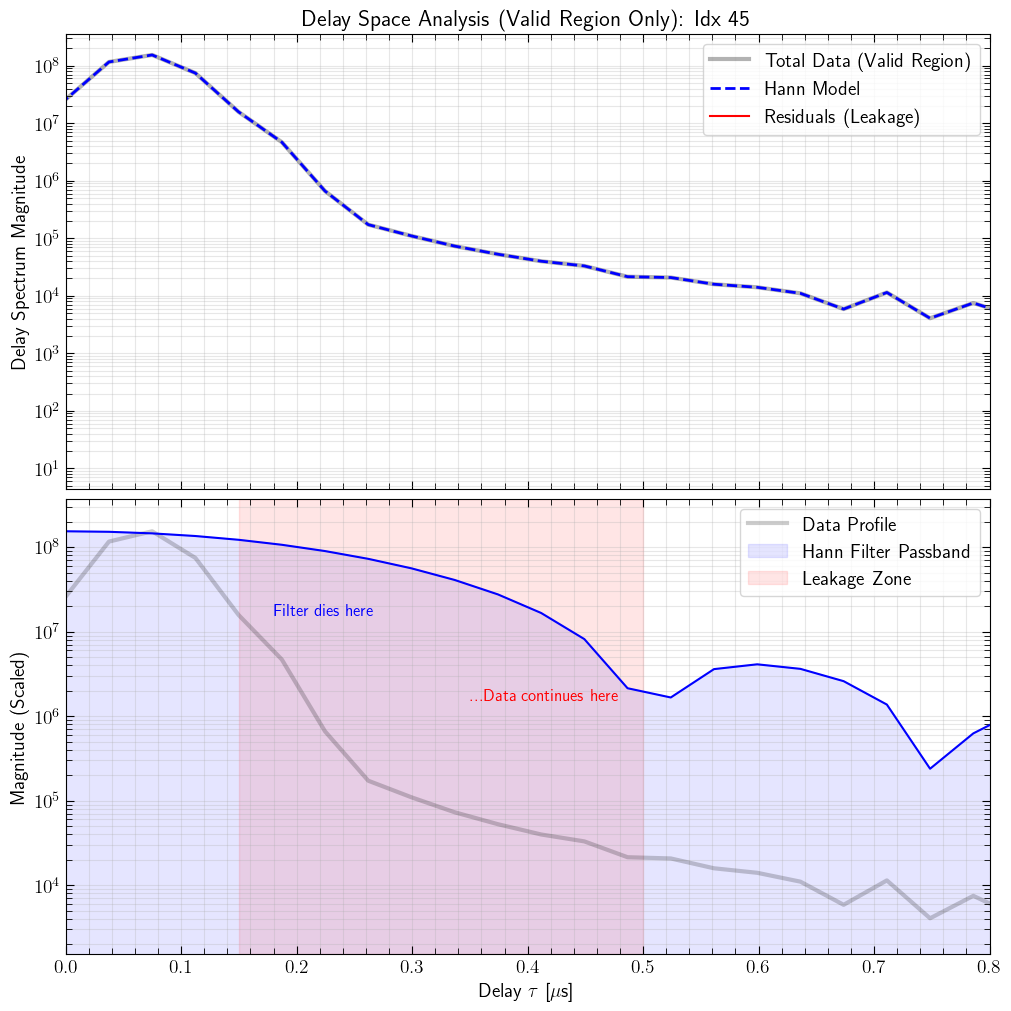

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.fft import fft, fftshift, fftfreq

# --- Input Model Parameters (Kept exactly as yours) ---
n = 2.0
N = 768
dnuc = 40e-3             # MHz
r = 9209.714526830916    # Mpc
rp = 16.98990953034521   # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100

# Try loading nua, else create dummy frequency array
try:
    nua = np.load('nua.npy') / 1e6
    dnu = nua
except FileNotFoundError:
    print("Warning: 'nua.npy' not found. Using linear range.")
    dnu = np.arange(N) * dnuc + 138.0 

# --- Configuration ---
path = "results"
flag_mode = "PERIODIC"  
NN_hann = 50 
idx_plot = 45 # Using idx1 for this analysis

# --- Helper to load data (Kept exactly as yours) ---
def get_data(inp_sig, scf_method, idx):
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None, None
    data = np.load(fname)
    orig = data.get("fields_orig", None)
    val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
    
    # NOTE: Assuming 'fields_res' exists for residuals. 
    # If your file saves 'fields_res', we use it. If not, we might need to assume 
    # the code structure you used before implies we calculate it or it's there.
    # For now, I will grab 'fields_res' if available, otherwise calculate from Total-Smooth if Smooth exists
    # But standard SCF output usually has Total and Flag/Res.
    
    if "fields_res" in data:
        resid = data["fields_res"][idx]
    else:
        # Fallback if specific key is missing (adjust as needed for your file structure)
        resid = np.zeros_like(data["fields_tota"][idx]) 
        print("Warning: fields_res not found")

    return data["fields_tota"][idx], resid, val_orig

# --- FFT Helper Function ---
def compute_delay_spec(signal_array):
    """
    Computes Delay Spectrum for a given 1D signal array.
    Applies Blackman-Harris window to suppress FFT edge ringing.
    """
    # 1. Remove mean (DC component) to see structure better? 
    # Usually better to keep it to see the "Main Lobe".
    
    # 2. Apply Windowing (Blackman-Harris) to suppress spectral leakage from finite bandwidth
    window_fft = np.blackman(len(signal_array))
    sig_win = signal_array * window_fft
    
    # 3. FFT
    sig_tau = fftshift(fft(sig_win))
    
    # 4. Delay Axis
    # Frequency step is dnuc. Bandwidth is len(signal)*dnuc.
    # Delays = fftfreq
    delays = fftshift(fftfreq(len(signal_array), d=dnuc))
    
    return delays, np.abs(sig_tau)

# --- Theoretical Hann Transfer Function ---
def get_hann_transfer(N_valid_points, N_half_width):
    """
    Computes the theoretical Transfer Function of the Hann filter 
    as it would appear on the Valid Grid.
    """
    # We construct the Hann window in a buffer of the same size as our analysis region
    win = np.zeros(N_valid_points)
    
    # The effective width in the valid region analysis
    # We create a window centered in this frame
    hann = np.hanning(2 * N_half_width)
    
    # Center it
    center = N_valid_points // 2
    # Handle indices carefully
    start = center - N_half_width
    end = center + N_half_width
    
    # Clip if window is larger than array (unlikely here but good practice)
    h_start = 0
    h_end = 2 * N_half_width
    
    if start < 0:
        h_start = -start
        start = 0
    if end > N_valid_points:
        h_end = h_end - (end - N_valid_points)
        end = N_valid_points
        
    win[start:end] = hann[h_start:h_end]
    win /= win.sum() # Normalize
    
    # FFT (No windowing for the Transfer Function itself)
    W_tau = np.abs(fftshift(fft(win)))
    return W_tau


# --- MAIN ANALYSIS ---

# 1. Load Data
tota_fg, res_hann, _ = get_data("FG+MM+21cm", "Hann", idx=idx_plot)

if tota_fg is not None:
    
    # 2. Extract VALID Region Only
    # You mentioned Hann is valid only inside [NN : -NN]
    valid_slice = slice(NN_hann, -NN_hann)
    
    # We analyze ONLY this valid region to prove the failure is not edge effects
    data_valid = tota_fg[valid_slice]
    res_valid  = res_hann[valid_slice]
    model_valid = data_valid - res_valid # Reconstruct the smooth model
    
    # 3. Compute Spectra in Delay Space
    delays, spec_data = compute_delay_spec(data_valid)
    _, spec_model     = compute_delay_spec(model_valid)
    _, spec_res       = compute_delay_spec(res_valid)
    
    # 4. Compute Theoretical Filter Response (Scaled to data peak)
    W_response = get_hann_transfer(len(data_valid), NN_hann)
    scale_factor = np.max(spec_data)
    
    # --- PLOTTING ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    plt.subplots_adjust(hspace=0.1)

    # PANEL A: Components
    ax0 = axes[0]
    ax0.plot(delays, spec_data, 'k-', lw=3, alpha=0.3, label='Total Data (Valid Region)')
    ax0.plot(delays, spec_model, 'b--', lw=2, label='Hann Model')
    ax0.plot(delays, spec_res, 'r-', lw=1.5, label='Residuals (Leakage)')
    
    ax0.set_yscale('log')
    ax0.set_ylabel(r'Delay Spectrum Magnitude')
    ax0.set_title(f'Delay Space Analysis (Valid Region Only): Idx {idx_plot}')
    ax0.legend()
    ax0.grid(True, which='both', alpha=0.3)
    
    # PANEL B: Geometry / Mismatch
    ax1 = axes[1]
    
    # 1. The Data Outline
    ax1.plot(delays, spec_data, 'k-', lw=3, alpha=0.2, label='Data Profile')
    
    # 2. The Filter "Bucket"
    ax1.fill_between(delays, W_response * scale_factor, color='blue', alpha=0.1, label='Hann Filter Passband')
    ax1.plot(delays, W_response * scale_factor, 'b-', lw=1.5)
    
    # 3. The Unsmooth Tail (Leakage)
    # Find where Data > Filter (approximate crossing point)
    # This is usually around 0.1 - 0.2 us depending on params
    ax1.axvspan(0.15, 0.5, color='red', alpha=0.1, label='Leakage Zone')
    
    # Annotations
    ax1.text(0.18, scale_factor*0.1, "Filter dies here", color='blue', fontsize=12, fontweight='bold')
    ax1.text(0.35, scale_factor*0.01, "...Data continues here", color='red', fontsize=12, fontweight='bold')

    ax1.set_yscale('log')
    ax1.set_xlabel(r'Delay $\tau$ [$\mu$s]')
    ax1.set_ylabel(r'Magnitude (Scaled)')
    ax1.set_xlim(0, 0.8) # Zoom in on relevant positive delays
    ax1.set_ylim(bottom=scale_factor * 1e-5) # Adjust dynamic range
    ax1.legend(loc='upper right')
    ax1.grid(True, which='both', alpha=0.3)
    
    save_fname = f"plots/Delay_Analysis_Hann_Valid_{flag_mode}.pdf"
    os.makedirs(os.path.dirname(save_fname), exist_ok=True)
    plt.savefig(save_fname, bbox_inches='tight')
    print(f"Saved: {save_fname}")
    plt.show()

else:
    print("Data load failed.")

In [7]:
# plot window

/tmp/ipykernel_249602/762837962.py:81: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


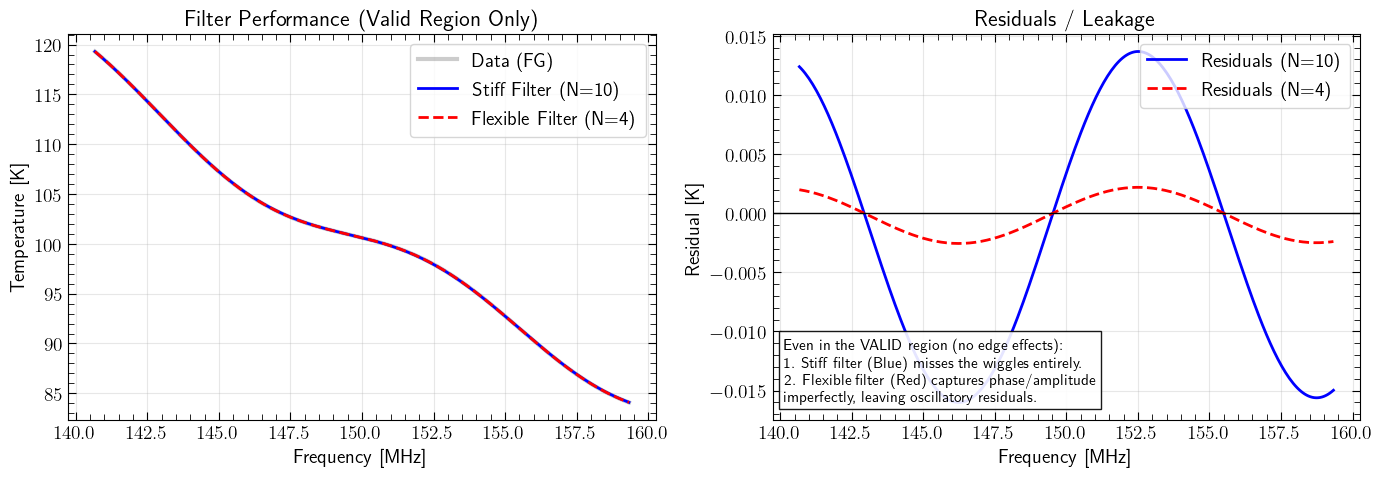

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Frequency and Delays
nu = np.linspace(140, 160, 300)  # MHz, increased resolution
dnu = nu[1] - nu[0]

# 2. Define Foregrounds
# A. Smooth Component (Power law)
fg_smooth = 100 * (nu / 150.0)**-2.5

# B. Unsmooth Component (Mode Mixing / Standing Wave)
# A sine wave representing structure at intermediate delay
k_unsmooth = 0.080 # modulation frequency
fg_unsmooth = 2.0 * np.cos(2 * np.pi * k_unsmooth * (nu - 140))

# Total Data
data = fg_smooth + fg_unsmooth

# 3. Define Hann Filter Function
def apply_hann_filter(signal, N_half_width):
    # Create Hann window of full width 2*N
    window = np.hanning(2 * N_half_width+1)
    window = window / window.sum() # Normalize
    
    # Apply convolution 
    model = np.convolve(signal, window, mode='same')
    return model

# 4. Apply Filters with different widths
N_strict = 10     # Wide Window (Stiff)
N_aggressive = 4 # Narrow Window (Flexible)

model_strict = apply_hann_filter(data, N_half_width=N_strict)
model_aggressive = apply_hann_filter(data, N_half_width=N_aggressive)

# 5. DEFINE VALID REGION
# We discard the max window width from both ends to be safe
# This ensures we are looking ONLY at the "safe" center
edge_cut = max(N_strict, N_aggressive)
valid = slice(edge_cut, -edge_cut)

nu_valid = nu[valid]
res_strict = (data - model_strict)[valid]
res_aggressive = (data - model_aggressive)[valid]

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: The Models vs Data (Valid Region Only)
axes[0].plot(nu_valid, data[valid], 'k-', alpha=0.2, lw=3, label='Data (FG)')
axes[0].plot(nu_valid, model_strict[valid], 'b-', lw=2, label=f'Stiff Filter (N={N_strict})')
axes[0].plot(nu_valid, model_aggressive[valid], 'r--', lw=2, label=f'Flexible Filter (N={N_aggressive})')
axes[0].set_title("Filter Performance (Valid Region Only)")
axes[0].set_xlabel("Frequency [MHz]")
axes[0].set_ylabel("Temperature [K]")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: The Residuals (The Failure)
axes[1].plot(nu_valid, res_strict, 'b-', label=f'Residuals (N={N_strict})')
axes[1].plot(nu_valid, res_aggressive, 'r--', label=f'Residuals (N={N_aggressive})')
axes[1].axhline(0, color='k', lw=1)
axes[1].set_title("Residuals / Leakage")
axes[1].set_xlabel("Frequency [MHz]")
axes[1].set_ylabel("Residual [K]")
# axes[1].set_ylim(-2.5, 2.5) 
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Annotation
text = (
    "Even in the VALID region (no edge effects):\n"
    "1. Stiff filter (Blue) misses the wiggles entirely.\n"
    "2. Flexible filter (Red) captures phase/amplitude\n"
    "   imperfectly, leaving oscillatory residuals."
)
axes[1].text(0.02, 0.05, text, transform=axes[1].transAxes, 
             bbox=dict(facecolor='white', alpha=0.9), fontsize=11)

plt.tight_layout()
plt.show()

In [9]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.fft import fft, fftshift, fftfreq

# # === Parameters (Same as above) ===
# N_chan = 768
# dnu = 0.04 
# tau = fftshift(fftfreq(N_chan, dnu))
# mask = tau >= 0

# # === Function (Same as above) ===
# def get_transfer_curve(N_half):
#     win = np.zeros(N_chan)
#     hann = np.hanning(2 * N_half )
#     center = N_chan // 2
#     win[center - N_half : center + N_half] = hann
#     win /= win.sum() 
#     return np.abs(fftshift(fft(win)))[mask]

# # === Generate Curves & Convert to dB ===
# tau_plot = tau[mask]
# W_stiff = get_transfer_curve(50) 
# W_flex = get_transfer_curve(10)

# # Add tiny epsilon to avoid log(0) error
# epsilon = 1e-15
# W_stiff_db = W_stiff + epsilon # 20 * np.log10(W_stiff + epsilon)
# W_flex_db = W_flex + epsilon # 20 * np.log10(W_flex + epsilon)
# # W_stiff_db =  20 * np.log10(W_stiff + epsilon)
# # W_flex_db =   20 * np.log10(W_flex + epsilon)

# # === PLOTTING ===
# fig, ax = plt.subplots(figsize=(8, 5))

# # 1. Reference Lines
# ax.axhline(0, color='k', linestyle='--', lw=1, label='0 dB (Perfect Pass)')

# # 2. Plot Filter Responses in dB
# ax.plot(tau_plot, W_stiff_db, 'b-', lw=1.5, label='Stiff Filter ($N=50$)')
# ax.plot(tau_plot, W_flex_db, 'r-', lw=1.5, alpha=0.8, label='Flexible Filter ($N=10$)')

# # 3. Annotate Regions
# # Main Lobe Region
# ax.axvspan(0, 0.1, color='gray', alpha=0.1)
# ax.text(0.05, -10, "Main Lobe\n(Foreground Region)", ha='center', fontsize=10)

# # Sidelobe Region
# ax.axvspan(0.2, 0.5, color='blue', alpha=0.05)
# ax.text(0.35, -60, "Sidelobes\n(Signal Region)", ha='center', color='blue', fontsize=10)

# # Annotation for non-zero response
# ax.annotate('Non-zero response\ncauses signal distortion', 
#             xy=(0.3, -35), xytext=(0.3, -15),
#             arrowprops=dict(facecolor='red', arrowstyle='->'),
#             fontsize=10, color='red', ha='center')

# # 4. Formatting
# ax.set_xlim(0, 2)
# # ax.set_ylim(-100, 5)
# ax.set_xlabel(r'Delay $\tau$ [$\mu$s]', fontsize=12)
# ax.set_ylabel(r'Filter Response [dB]', fontsize=12)
# ax.set_title('Log Scale: Sidelobe Structure and Signal Distortion', fontsize=13)
# ax.legend(loc='upper right')
# ax.grid(True, alpha=0.3)
# # plt.xscale('log')
# plt.yscale('log')
# ax.set_ylim(1e-4)

# plt.tight_layout()
# # Save this as fig_transfer_log.pdf
# # plt.savefig('fig_transfer_log.pdf')
# # plt.show()

In [10]:
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# # --- Input Model Parameters ---
# n = 2.0
# N = 768
# dnuc = 40e-3             # MHz
# r = 9209.714526830916    # Mpc
# rp = 16.98990953034521   # Mpc/MHz
# dL = dnuc * rp
# L  = N * dL
# Nrea = 100

# # Try loading nua, else create dummy frequency array
# try:
#     nua = np.load('nua.npy') / 1e6
#     dnu = nua
# except FileNotFoundError:
#     print("Warning: 'nua.npy' not found. Using linear range.")
#     dnu = np.arange(N) * dnuc + 138.0 

# # --- Configuration ---
# path = "results"
# flag_mode = "PERIODIC"
# NN_hann = 50 
# show_inset = False 

# # INDICES for the two realizations
# idx1 = 45
# idx2 = 90 

# # --- Helper to load data ---
# def get_data(inp_sig, scf_method, idx):
#     fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
#     if not os.path.exists(fname):
#         print(f"File not found: {fname}")
#         return None, None, None
#     data = np.load(fname)
    
#     # Safe load for fields_orig
#     orig = data.get("fields_orig", None)
#     val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
        
#     return data["fields_tota"][idx], data["fields_flag"][idx], val_orig

# # --- Plotting Logic ---
# def plot_realization(ax_top, ax_mid, ax_bot, idx, show_ylabel=True, show_legend=False):
#     # 1. Load Main Results (FG + 21cm)
#     tota_fg_hann, res_hann, _ = get_data("FG+MM+21cm", "Hann", idx=idx) 
#     tota_fg_gp,   res_gp, _   = get_data("FG+MM+21cm", "GP",   idx=idx) 
    
#     # 2. Load "True" 21cm Filtered Signals (The Truth)
#     _, true_21cm_res_hann, _ = get_data("21cm", "Hann", idx=idx)
#     _, true_21cm_res_gp, _   = get_data("21cm", "GP",   idx=idx)

#     if res_hann is None or res_gp is None:
#         print(f"Error: Missing files for idx {idx}.")
#         return

#     # Data Prep
#     x_full = dnu
#     flag_mask = (res_gp != 0.0)
    
#     # Mask Total Input
#     tota_fg_flagged = tota_fg_gp.copy()
#     tota_fg_flagged[~flag_mask] = np.nan 
    
#     # Calculate Fits
#     fit_gp = tota_fg_gp - res_gp
#     fit_gp[~flag_mask] = np.nan
    
#     x_hann = x_full[NN_hann : -NN_hann]
#     tota_hann_cut = tota_fg_hann[NN_hann : -NN_hann]
#     fit_hann = tota_hann_cut - res_hann
#     mask_hann = flag_mask[NN_hann : -NN_hann]
#     fit_hann[~mask_hann] = np.nan
    
#     # Mask Residuals (Data)
#     res_gp_masked = res_gp.copy()
#     res_gp_masked[~flag_mask] = np.nan
    
#     res_hann_masked = res_hann.copy()
#     res_hann_masked[res_hann_masked == 0] = np.nan 
    
#     # Mask "True" 21cm Residuals (Apply same flags)
    
#     # GP Truth
#     true_21cm_gp_masked = true_21cm_res_gp.copy()
#     true_21cm_gp_masked[~flag_mask] = np.nan
    
#     # Hann Truth (Handle potential trimming)
#     if len(true_21cm_res_hann) == N:
#         true_21cm_hann_cut = true_21cm_res_hann[NN_hann : -NN_hann]
#     else:
#         true_21cm_hann_cut = true_21cm_res_hann
    
#     true_21cm_hann_masked = true_21cm_hann_cut.copy()
#     true_21cm_hann_masked[~mask_hann] = np.nan

#     # --- GLOBAL FONT SIZES ---
#     FS_LABEL = 18 
#     FS_TICK  = 15 
#     FS_LEG   = 13 

#     for ax in [ax_top, ax_mid, ax_bot]:
#         ax.tick_params(axis='both', which='major', labelsize=FS_TICK)

#     # --- TOP PANEL: Input + Fits ---
#     ax_top.plot(x_full, tota_fg_flagged, color='k', linewidth=2, 
#                 label=r"$\mathrm{FG\ (unsmooth) + 21\mbox{-}cm}$") 
#     ax_top.plot(x_hann, fit_hann, color='tab:blue', linestyle='--', linewidth=1.5, 
#                 label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(Hann)}$')
#     ax_top.plot(x_full, fit_gp, color='tab:orange', linestyle='-.', linewidth=1.5, 
#                 label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(GP)}$')
    
#     if show_ylabel:
#         ax_top.set_ylabel(r"$T\ \mathrm{mK}$", fontsize=FS_LABEL)
#     if show_legend:
#         ax_top.legend(loc="upper right", frameon=True, fontsize=FS_LEG) 
        
#     # --- MIDDLE PANEL: Hann Residuals ---
#     # Truth (Solid Blue)
#     ax_mid.plot(x_hann, true_21cm_hann_masked, color='k', linestyle='-', linewidth=2, alpha=0.99,
#              label=r'$T_{21}^{\mathrm{F}}(\nu) \ \mathrm{(Hann)}$')
#     # Data (Dashed Blue, Scaled)
#     ax_mid.plot(x_hann, res_hann_masked/100, color='tab:blue', linestyle='--', alpha=0.7, 
#              label=r'$10^{-2} \times T^{\mathrm{F}}(\nu) \ \mathrm{(Hann)}$')
    
#     if show_ylabel:
#         ax_mid.set_ylabel(r"$T\ \mathrm{mK}$", fontsize=FS_LABEL)
#     if show_legend:
#         ax_mid.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)

#     # --- BOTTOM PANEL: GP Residuals ---
#     # Truth (Solid Orange)
#     ax_bot.plot(x_full, true_21cm_gp_masked, color='k', linestyle='-', linewidth=2, alpha=0.99,
#              label=r'$T_{21}^{\mathrm{F}}(\nu) \ \mathrm{(GP)}$')
#     # Data (Dash-Dot Orange)
#     ax_bot.plot(x_full, res_gp_masked, color='tab:orange', linestyle='--', alpha=0.8, 
#              label=r'$T^{\mathrm{F}}(\nu) \ \mathrm{(GP)}$')
    
#     if show_ylabel:
#         ax_bot.set_ylabel(r"$T \ \mathrm{mK}$", fontsize=FS_LABEL)
    
#     ax_bot.set_xlabel(r"$\nu \ \mathrm{MHz}$", fontsize=FS_LABEL)
#     if show_legend:
#         ax_bot.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)


# # --- MAIN DRIVER ---
# # 3 Rows, 2 Columns
# fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey='row')

# # Plot Realization 1 (Left Column)
# plot_realization(axes[0, 0], axes[1, 0], axes[2, 0], idx1, show_ylabel=True, show_legend=True)

# # Plot Realization 2 (Right Column)
# plot_realization(axes[0, 1], axes[1, 1], axes[2, 1], idx2, show_ylabel=False, show_legend=False)

# plt.tight_layout()

# save_fname = f"plots/Hann_GP_comparison_{flag_mode}_3panel.pdf"
# os.makedirs(os.path.dirname(save_fname), exist_ok=True)
# plt.savefig(save_fname, dpi=300, bbox_inches='tight')
# print(f"Saved: {save_fname}")

# plt.show()

In [11]:
# # import numpy as np
# # import matplotlib.pyplot as plt
# # import os
# # from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# # # --- Input Model Parameters ---
# # n = 2.0
# # N = 768
# # dnuc = 40e-3             # MHz
# # r = 9209.714526830916    # Mpc
# # rp = 16.98990953034521   # Mpc/MHz
# # dL = dnuc * rp
# # L  = N * dL
# # Nrea = 100

# # # Try loading nua, else create dummy frequency array
# # try:
# #     nua = np.load('nua.npy') / 1e6
# #     dnu = nua
# # except FileNotFoundError:
# #     print("Warning: 'nua.npy' not found. Using linear range.")
# #     dnu = np.arange(N) * dnuc + 138.0 

# # # --- Configuration ---
# # path = "results"
# # flag_mode = "PERIODIC"
# # NN_hann = 50 
# # show_inset = False 

# # # INDICES for the two realizations
# # idx1 = 45
# # idx2 = 90 

# # # --- Helper to load data ---
# # # UPDATED: Added flag_arg to allow overriding the global flag_mode
# # def get_data(inp_sig, scf_method, idx, flag_arg=flag_mode):
# #     fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_arg}_SCF-{scf_method}.npz"
# #     if not os.path.exists(fname):
# #         print(f"File not found: {fname}")
# #         return None, None, None
# #     data = np.load(fname)
    
# #     orig = data.get("fields_orig", None)
# #     val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
        
# #     return data["fields_tota"][idx], data["fields_flag"][idx], val_orig

# # # --- Plotting Logic ---
# # def plot_realization(ax_top, ax_mid, ax_bot, idx, show_ylabel=True, show_legend=False):
# #     # 1. Load Main Results (FG + 21cm) -> Uses PERIODIC flags
# #     tota_fg_hann, res_hann, _ = get_data("FG+MM+21cm", "Hann", idx=idx, flag_arg=flag_mode) 
# #     tota_fg_gp,   res_gp, _   = get_data("FG+MM+21cm", "GP",   idx=idx, flag_arg=flag_mode) 
    
# #     # 2. Load "True" 21cm Filtered Signals -> Uses NOFLAG (Continuous Truth)
# #     # This allows us to see how well we recover the signal "under the flags"
# #     _, true_21cm_res_hann, _ = get_data("21cm", "Hann", idx=idx, )
# #     _, true_21cm_res_gp, _   = get_data("21cm", "GP",   idx=idx, )

# #     if res_hann is None or res_gp is None:
# #         print(f"Error: Missing files for idx {idx}.")
# #         return

# #     # Data Prep
# #     x_full = dnu
    
# #     # Identify Flags from the main run
# #     flag_mask = (res_gp != 0.0)
    
# #     # Mask Total Input (Keep gaps to show data loss)
# #     tota_fg_flagged = tota_fg_gp.copy()
# #     tota_fg_flagged[~flag_mask] = np.nan 
    
# #     # Calculate Fits
# #     fit_gp = tota_fg_gp - res_gp
# #     fit_gp[~flag_mask] = np.nan
    
# #     x_hann = x_full[NN_hann : -NN_hann]
# #     tota_hann_cut = tota_fg_hann[NN_hann : -NN_hann]
# #     fit_hann = tota_hann_cut - res_hann
# #     mask_hann = flag_mask[NN_hann : -NN_hann]
# #     fit_hann[~mask_hann] = np.nan
    
# #     # Mask Residuals (Data has gaps)
# #     res_gp_masked = res_gp.copy()
# #     res_gp_masked[~flag_mask] = np.nan
    
# #     res_hann_masked = res_hann.copy()
# #     res_hann_masked[res_hann_masked == 0] = np.nan 
    
# #     # PREPARE TRUTH (NO MASKS APPLIED - CONTINUOUS)
    
# #     # GP Truth (Full band, Continuous)
# #     true_21cm_gp_cont = true_21cm_res_gp
    
# #     # Hann Truth (Sliced band, Continuous)
# #     if len(true_21cm_res_hann) == N:
# #         true_21cm_hann_cut = true_21cm_res_hann[NN_hann : -NN_hann]
# #     else:
# #         true_21cm_hann_cut = true_21cm_res_hann
# #     true_21cm_hann_cont = true_21cm_hann_cut

# #     # --- GLOBAL FONT SIZES ---
# #     FS_LABEL = 18 
# #     FS_TICK  = 15 
# #     FS_LEG   = 13 

# #     for ax in [ax_top, ax_mid, ax_bot]:
# #         ax.tick_params(axis='both', which='major', labelsize=FS_TICK)

# #     # --- TOP PANEL: Input + Fits ---
# #     ax_top.plot(x_full, tota_fg_flagged, color='k', linewidth=2, 
# #                 label=r"$\mathrm{FG\ (unsmooth) + 21\mbox{-}cm}$") 
# #     ax_top.plot(x_hann, fit_hann, color='tab:blue', linestyle='--', linewidth=1.5, 
# #                 label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(Hann)}$')
# #     ax_top.plot(x_full, fit_gp, color='tab:orange', linestyle='-.', linewidth=1.5, 
# #                 label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(GP)}$')
    
# #     if show_ylabel:
# #         ax_top.set_ylabel(r"$T$ mK", fontsize=FS_LABEL)
# #     if show_legend:
# #         ax_top.legend(loc="upper right", frameon=True, fontsize=FS_LEG) 
        
# #     # --- MIDDLE PANEL: Hann Residuals ---
# #     # Truth (Solid Black, Continuous)
# #     ax_mid.plot(x_hann, true_21cm_hann_cont, color='k', linestyle='-', linewidth=2, alpha=0.9,
# #              label=r'$T_{21}^{\mathrm{F}}(\nu) \ \mathrm{(Hann)}$')
# #     # Data (Dashed Blue, Scaled, Gapped)
# #     ax_mid.plot(x_hann, res_hann_masked/1e2, color='tab:blue', linestyle='--', alpha=0.7, 
# #              label=r'$10^{-2} \times T^{\mathrm{F}}(\nu) \ \mathrm{(Hann)}$')
    
# #     if show_ylabel:
# #         ax_mid.set_ylabel(r"$T$ mK", fontsize=FS_LABEL)
# #     if show_legend:
# #         ax_mid.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)

# #     # --- BOTTOM PANEL: GP Residuals ---
# #     # Truth (Solid Black, Continuous)
# #     ax_bot.plot(x_full, true_21cm_gp_cont, color='k', linestyle='-', linewidth=2, alpha=0.9,
# #              label=r'$T_{21}^{\mathrm{F}}(\nu) \ \mathrm{(GP)}$')
# #     # Data (Dotted Orange, Gapped)
# #     ax_bot.plot(x_full, res_gp_masked, color='tab:orange', linestyle='-', alpha=0.8, linewidth=2,
# #              label=r'$T^{\mathrm{F}}(\nu) \ \mathrm{(GP)}$')
    
# #     if show_ylabel:
# #         ax_bot.set_ylabel(r"$T$ mK", fontsize=FS_LABEL)
    
# #     ax_bot.set_xlabel(r"$\nu$ MHz", fontsize=FS_LABEL)
# #     if show_legend:
# #         ax_bot.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)


# # # --- MAIN DRIVER ---
# # fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey='row')

# # plot_realization(axes[0, 0], axes[1, 0], axes[2, 0], idx1, show_ylabel=True, show_legend=True)
# # plot_realization(axes[0, 1], axes[1, 1], axes[2, 1], idx2, show_ylabel=False, show_legend=False)

# # plt.tight_layout()
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# # --- Input Model Parameters ---
# n = 2.0
# N = 768
# dnuc = 40e-3             # MHz
# r = 9209.714526830916    # Mpc
# rp = 16.98990953034521   # Mpc/MHz
# dL = dnuc * rp
# L  = N * dL
# Nrea = 100

# # Try loading nua, else create dummy frequency array
# try:
#     nua = np.load('nua.npy') / 1e6
#     dnu = nua
# except FileNotFoundError:
#     print("Warning: 'nua.npy' not found. Using linear range.")
#     dnu = np.arange(N) * dnuc + 138.0 

# # --- Configuration ---
# path = "results"
# flag_mode = "PERIODIC"
# NN_hann = 50 
# show_inset = False 

# # INDICES for the two realizations
# idx1 = 45
# idx2 = 90 

# # --- Helper to load data ---
# # UPDATED: Added flag_arg to allow overriding the global flag_mode
# def get_data(inp_sig, scf_method, idx, flag_arg=flag_mode):
#     fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_arg}_SCF-{scf_method}.npz"
#     if not os.path.exists(fname):
#         print(f"File not found: {fname}")
#         return None, None, None
#     data = np.load(fname)
    
#     orig = data.get("fields_orig", None)
#     val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
        
#     return data["fields_tota"][idx], data["fields_flag"][idx], val_orig

# # --- Plotting Logic ---
# def plot_realization(ax_top, ax_mid, ax_bot, idx, show_ylabel=True, show_legend=False):
#     # 1. Load Main Results (FG + 21cm) -> Uses PERIODIC flags
#     tota_fg_hann, res_hann, _ = get_data("FG+MM+21cm", "Hann", idx=idx, flag_arg=flag_mode) 
#     tota_fg_gp,   res_gp, _   = get_data("FG+MM+21cm", "GP",   idx=idx, flag_arg=flag_mode) 
    
#     # 2. Load "True" 21cm Filtered Signals -> Uses NOFLAG (Continuous Truth)
#     # This allows us to see how well we recover the signal "under the flags"
#     _, true_21cm_res_hann, _ = get_data("21cm", "Hann", idx=idx, )
#     _, true_21cm_res_gp, _   = get_data("21cm", "GP",   idx=idx, )

#     if res_hann is None or res_gp is None:
#         print(f"Error: Missing files for idx {idx}.")
#         return

#     # Data Prep
#     x_full = dnu
    
#     # Identify Flags from the main run
#     flag_mask = (res_gp != 0.0)
    
#     # Mask Total Input (Keep gaps to show data loss)
#     tota_fg_flagged = tota_fg_gp.copy()
#     tota_fg_flagged[~flag_mask] = np.nan 
    
#     # Calculate Fits
#     fit_gp = tota_fg_gp - res_gp
#     fit_gp[~flag_mask] = np.nan
    
#     x_hann = x_full[NN_hann : -NN_hann]
#     tota_hann_cut = tota_fg_hann[NN_hann : -NN_hann]
#     fit_hann = tota_hann_cut - res_hann
#     mask_hann = flag_mask[NN_hann : -NN_hann]
#     fit_hann[~mask_hann] = np.nan
    
#     # Mask Residuals (Data has gaps)
#     res_gp_masked = res_gp.copy()
#     res_gp_masked[~flag_mask] = np.nan
    
#     res_hann_masked = res_hann.copy()
# plt.show()
# # save_fname = f"plots/Hann_GP_comparison_{flag_mode}_TruthNoFlag.pdf"
# # os.makedirs(os.path.dirname(save_fname), exist_ok=True)
# # plt.savefig(save_fname, dpi=300, bbox_inches='tight')
# # print(f"Saved: {save_fname}")

# # plt.show()